In [33]:
using PowerDynamics
using PowerDynamics: Library
using PowerDynamics.Library.ComposableInverter: SimpleGFLDC
using OrdinaryDiffEqRosenbrock
using OrdinaryDiffEqNonlinearSolve
using CairoMakie
using Graphs
using GraphPlot
using ModelingToolkit
using Accessors
using AccessorsExtra
using SparseArrays
using Symbolics
using LinearSolve
using DifferentialEquations
using JSON3
using Colors
using Plots
using Serialization

In [34]:
data = JSON3.read(read("names.json", String))
sol2 = deserialize("sim/btempTEST2.jld2")
println("finished")

finished


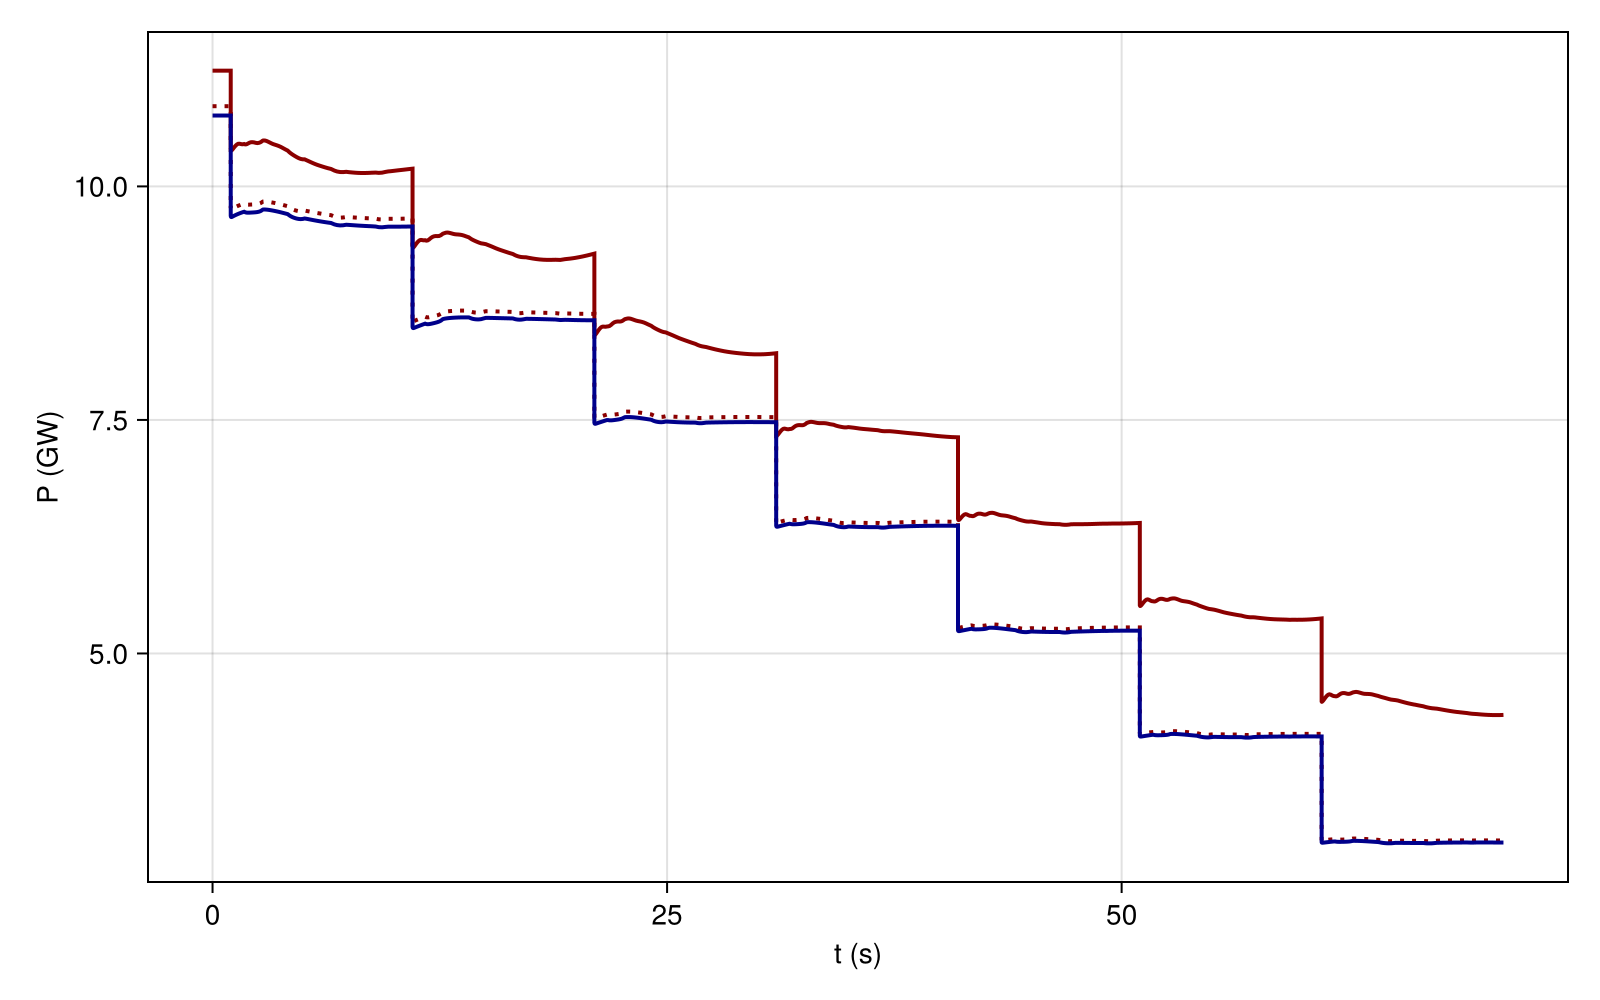

In [35]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t (s)", ylabel = "P (GW)")

    total_power = zeros(length(sol2.t))
    total_load = zeros(length(sol2.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "plant"
            total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total_load .-= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end
    end

    lines!(ax, sol2.t, total_power, color = :darkred, linewidth = 2)

    total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:Germany), :busbar₊P)).u
    total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:France), :busbar₊P)).u
    total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:Netherlands), :busbar₊P)).u

    lines!(ax, sol2.t, total_power, color = :darkred, linewidth = 2, linestyle = :dot)

    lines!(ax, sol2.t, total_load, color = :darkblue, linewidth = 2)

    fig
end

In [5]:
println(sol2(0, idxs=VIndex(Symbol("667172748_load"), :busbar₊P)))
println(sol2(0, idxs=VIndex(Symbol("667172748_load"), :load₊Pset)))

-0.1434451315789769
-0.1434451315789769


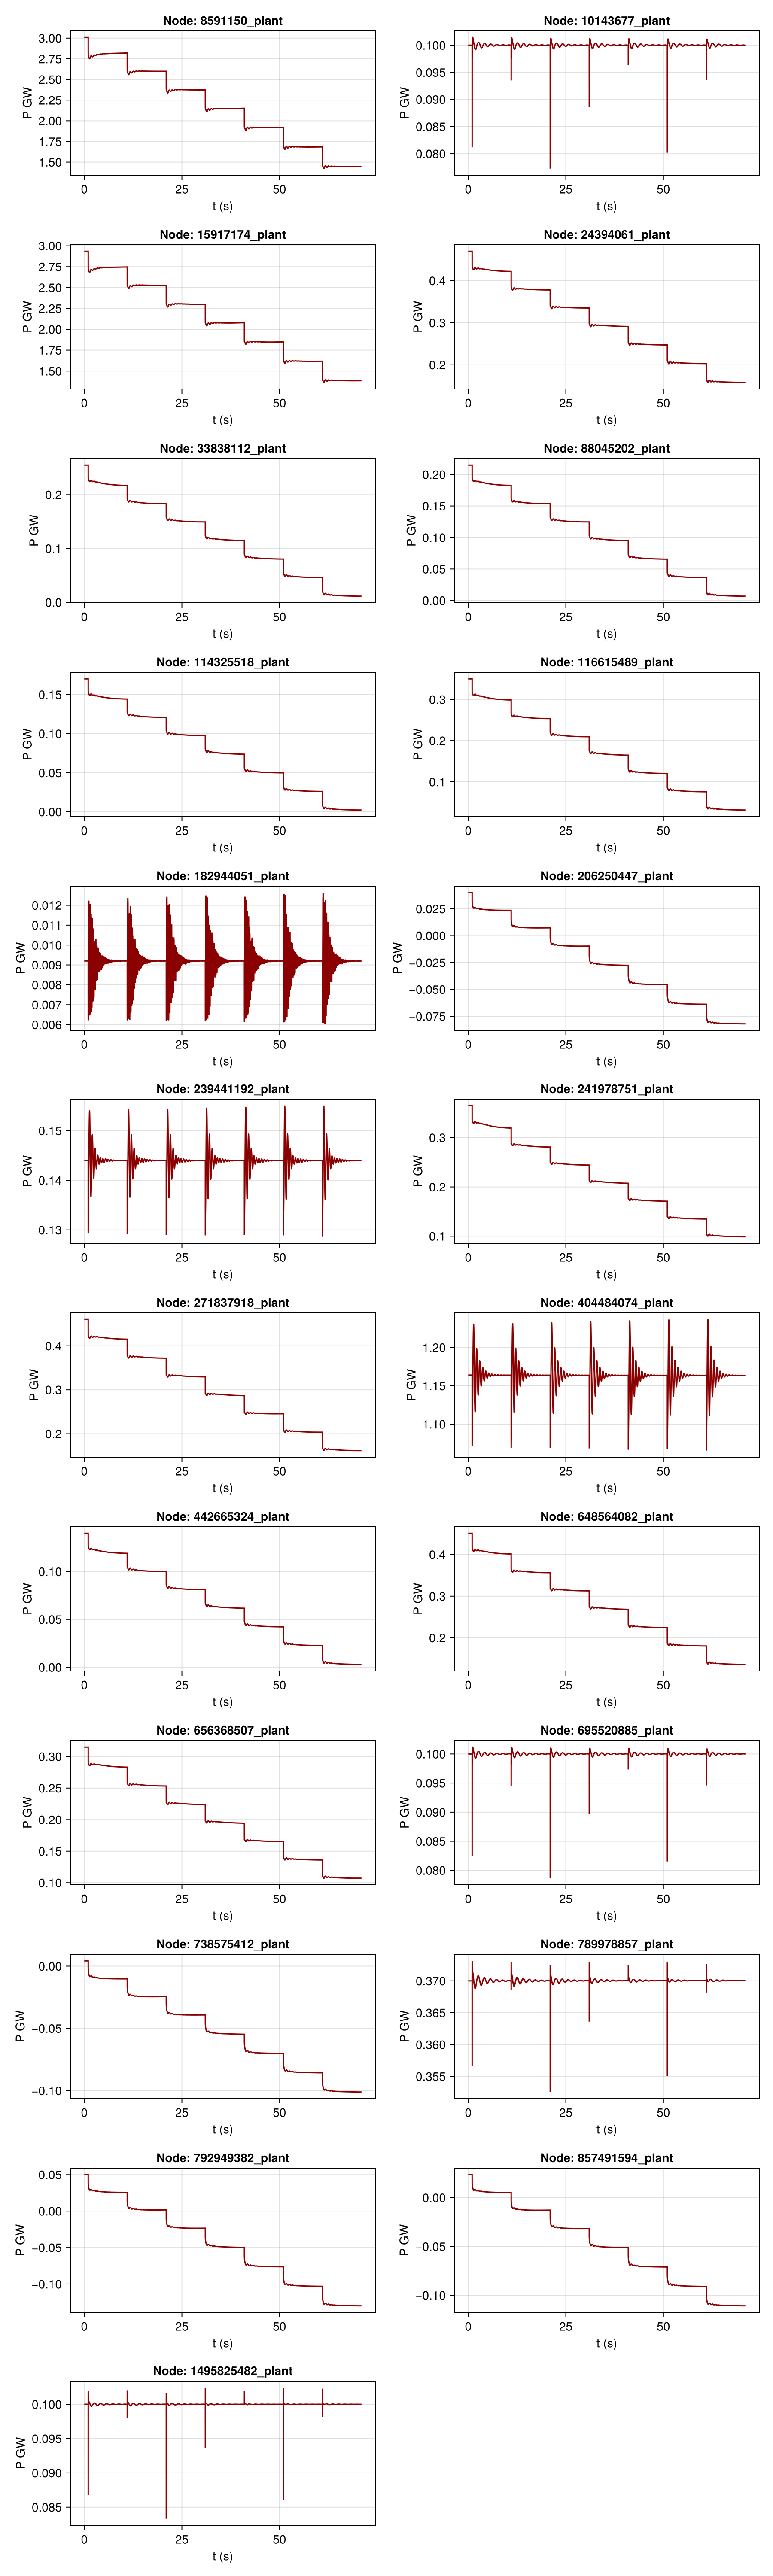

In [26]:
#plants
let
    fig = Figure(size = (900, 10 * 300))
    cols = 2

    i = 1
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2 || parts[2] != "plant"
            continue
        end
        
        row = (i - 1) ÷ cols + 1
        col = (i - 1) % cols + 1
        
        ax = Axis(fig[row, col], title="Node: $(name)", xlabel="t (s)", ylabel="P GW")
        try
        lines!(ax, sol2, idxs=VIndex(Symbol(name), :busbar₊P), color=:darkred)
        lines!(ax, sol2.t, total_load, color = :darkblue, linewidth = 2)
        catch
        end

        i += 1
    end
    
    fig
end

In [ ]:
H_vec = 4.2

Pgen = 0
Pload = 0
Ptie = 0
ω_coi = 0 

for name in data.nodes     
    parts = split(string(name), "_")

    if length(parts) != 2
        continue
    end

    if parts[2] == "plant"
        Pgen += sum(sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)))
        try
            H_vec = sol2(sol2.t, idxs=VIndex(Symbol(name), :ctrld_gen₊other₊H)).u
            Sn_vec = sol2(sol2.t, idxs=VIndex(Symbol(name), :ctrld_gen₊other₊Sn)).u
            ω_coi += sum(sol2(ts, idxs=vidxs(nw, gen_idxs, :ctrld_gen₊other₊ω)) .* (H_vec.*Sn_vec)) / sum(H_vec.*Sn_vec)
        catch
        end
    end

    if parts[2] == "load"
        Pload -= sum(sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)))
    end
end

for i in range(1, length(data.lines))
    Ptie += sum(sol2(sol2.t, idxs=EIndex(i, :src₊P)))
end

println(Pgen + Pload - Ptie)

# ω_coi = sum(sol2(sol2.t, idxs=VIndex(nw, gen_idxs, :machine₊ω)) .* (H_vec.*Sn_vec)) / sum(H_vec.*Sn_vec)       # must match the network loss computation
β_BE  = -diff(Pgen) ./ (50 .* diff(ω_coi))   # GW/Hz, per step
println(β_BE)

In [25]:
println(Pgen - Pload + Ptie)

-52841.89528900312


In [28]:
ω_coi

0

In [27]:
β_BE  = -Pgen ./ (50 .* ω_coi)

-Inf

In [ ]:

Pgen  = sum(sol(ts, idxs=vidxs(nw, gen_idxs, :machine₊Pout₊u)) .* Sn_vec) ./ 1000  # GW
Pload = sum(sol(ts, idxs=vidxs(nw, load_idxs, :load₊P)))
Ptie  = sum(sol(ts, idxs=eidxs(nw, tie_idxs, :src₊P)))

# ω_coi = sum(sol(ts, idxs=vidxs(nw, gen_idxs, :machine₊ω)) .* (H_vec.*Sn_vec)) / sum(H_vec.*Sn_vec)
Ploss = Pgen - Pload - Ptie          # must match the network loss computation
# β_BE  = -diff(Pgen) ./ (50 .* diff(ω_coi))   # GW/Hz, per step

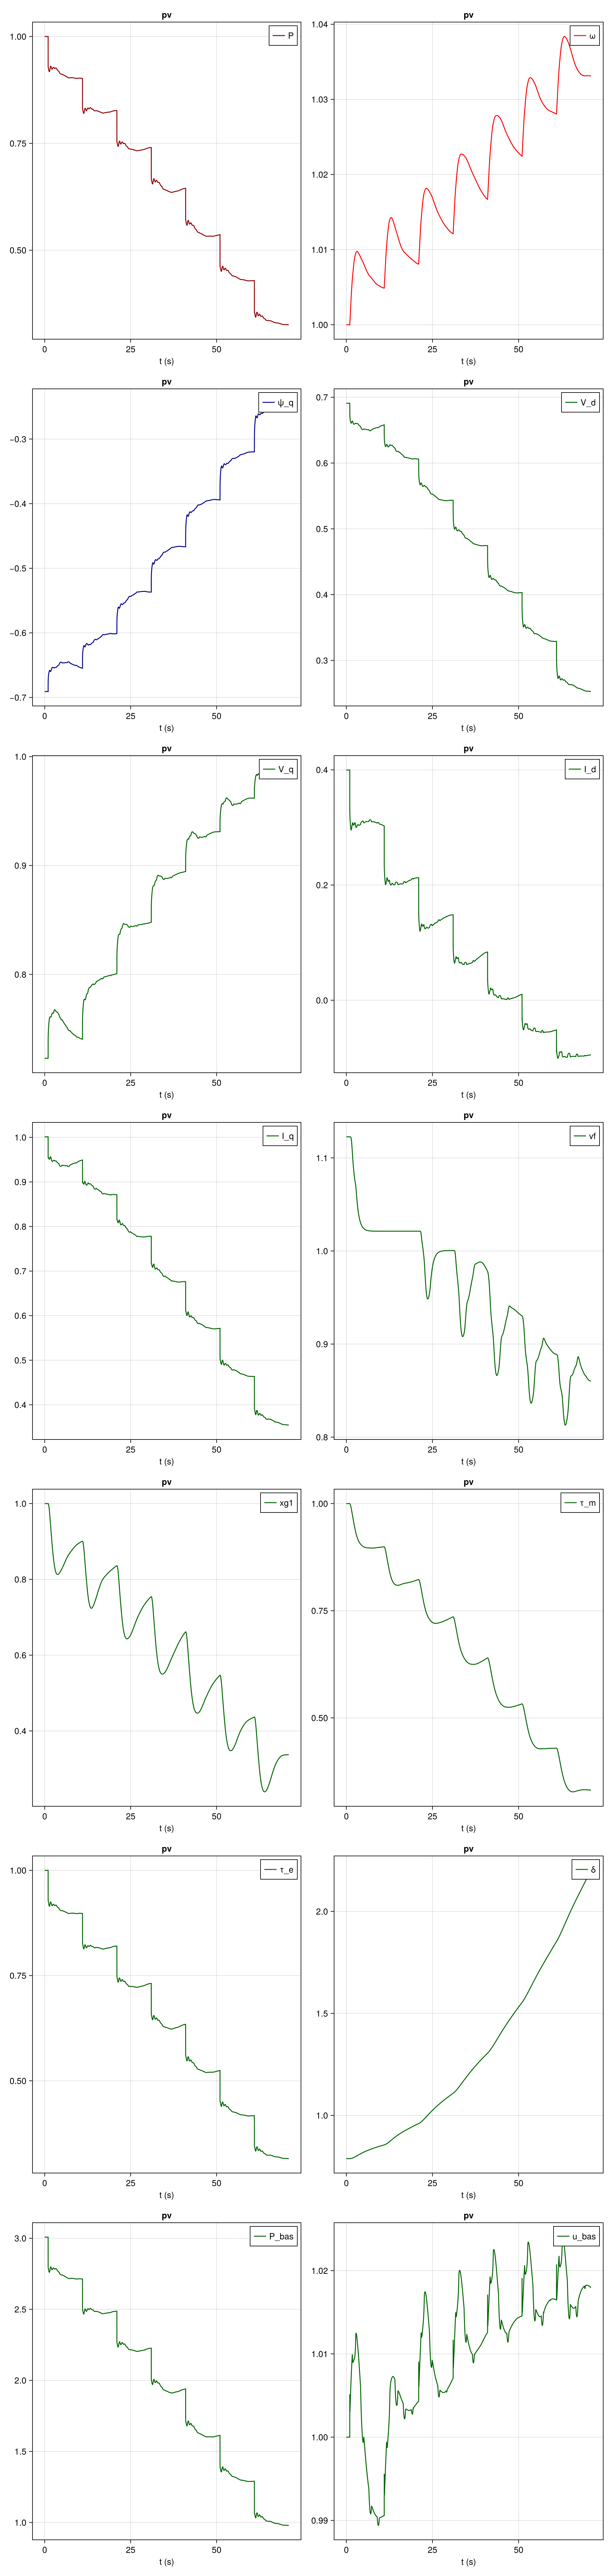

In [16]:
let
    cols = 2
    # Define the variables, their labels, and colors
    vars = [
        (:ctrld_gen₊other₊P, "P", :darkred),
        (:ctrld_gen₊other₊ω, "ω", :red),
        (:ctrld_gen₊other₊ψ_q, "ψ_q", :darkblue),
        (:ctrld_gen₊other₊V_d, "V_d", :darkgreen),
        (:ctrld_gen₊other₊V_q, "V_q", :darkgreen),
        (:ctrld_gen₊other₊I_d, "I_d", :darkgreen),
        (:ctrld_gen₊other₊I_q, "I_q", :darkgreen),
        (:ctrld_gen₊other₊vf, "vf", :darkgreen),
        (:ctrld_gen₊gov₊xg1, "xg1", :darkgreen),
        (:ctrld_gen₊other₊τ_m, "τ_m", :darkgreen),
        (:ctrld_gen₊other₊τ_e, "τ_e", :darkgreen),
        (:ctrld_gen₊other₊δ, "δ", :darkgreen),
        (:busbar₊P, "P_bas", :darkgreen),
        (:busbar₊u_mag, "u_bas", :darkgreen)
    ]
    
    # Calculate rows needed based on 2 columns
    rows = ceil(Int, length(vars))
    
    # Initialize figure with an appropriate size
    fig = Figure(size = (500 * cols, rows * 300))
    
    # Loop through and create a subplot for each variable
    for (i, (var_sym, label_str, col_color)) in enumerate(vars)
r = div(i - 1, cols) + 1
    c = mod(i - 1, cols) + 1
        
        # Create axis in the grid position (r, c)
        ax = Axis(fig[r, c], title="pv", xlabel="t (s)")
        # Plot the specific variable
        lines!(ax, sol2, idxs=VIndex(Symbol(data.nodes[1]), var_sym), color=col_color, label=label_str)

        axislegend(ax, position=:rt)

        # ax = Axis(fig[r, 2], title="slack", xlabel="t (s)")
        
        # lines!(ax, sol3, idxs=VIndex(Symbol(data.nodes[1]), var_sym), color=col_color, label=label_str)

        # axislegend(ax, position=:rt)
        
        # Optional: add legend per subplot if neede
    end
    
    fig
end

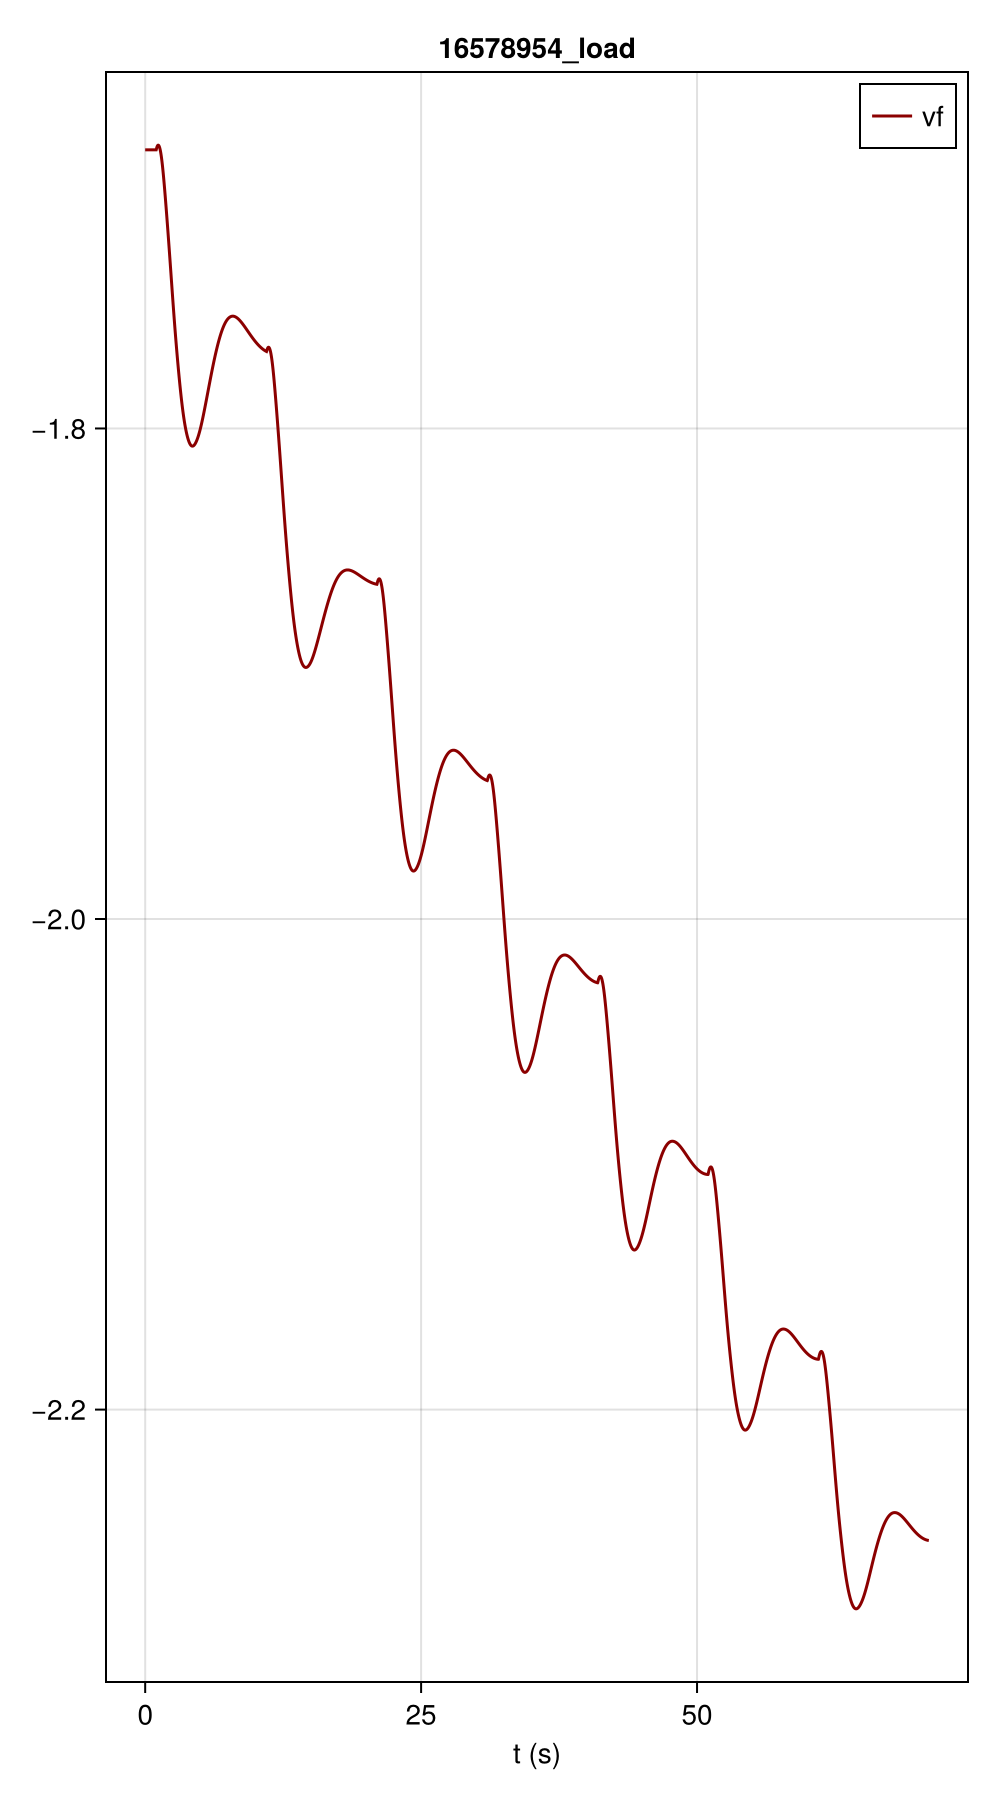

In [9]:
let
    fig = Figure()
    fig = Figure(size = (500, 3 * 300))
    cols = 1
    
    ax = Axis(fig[1, 1], title=data.nodes[495], xlabel="t (s)", ylabel="")
    
    # lines!(ax, sol2, idxs=VIndex(Symbol("France"), :ctrld_gen₊other₊τ_m), color=:darkblue, label="m")
    lines!(ax, sol2, idxs=VIndex(Symbol("Germany"), :ctrld_gen₊other₊τ_m ), color=:darkred, label="vf")
    # lines!(ax, sol2, idxs=VIndex(Symbol("France"), :busbar₊P), color=:darkgreen, label="P")
    # lines!(ax, sol2, idxs=VIndex(Symbol("738575412_plant"), :busbar₊P), color=:darkgreen, label="p")
    
    axislegend(ax, position=:rt)
    fig
end

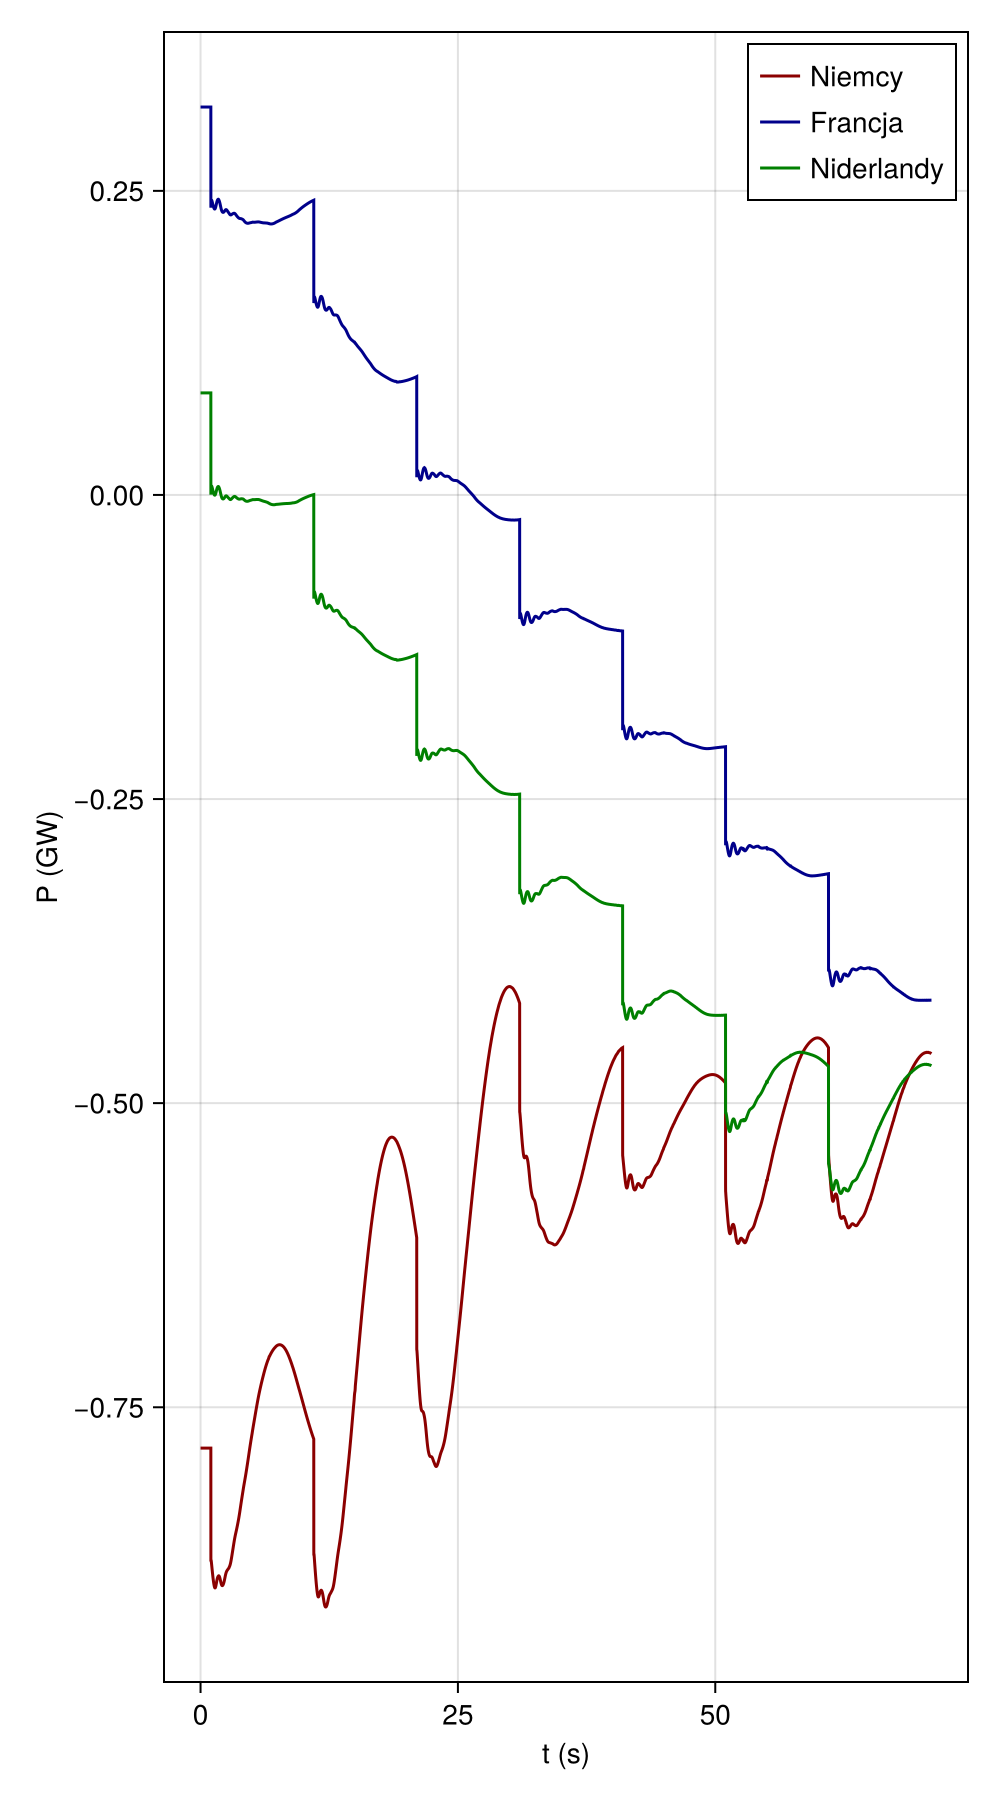

In [36]:
#slack
let
    fig = Figure()
    fig = Figure(size = (500, 3 * 300))
    cols = 2
    
    ax = Axis(fig[1, 1], title="", xlabel="t (s)", ylabel="P (GW)")
    
    lines!(ax, sol2, idxs=VIndex(:Germany, :busbar₊P), color=:darkred, label="Niemcy")
    lines!(ax, sol2, idxs=VIndex(:France, :busbar₊P), color=:darkblue, label="Francja")
    lines!(ax, sol2, idxs=VIndex(:Netherlands, :busbar₊P), color=:green, label="Niderlandy")
    
    axislegend(ax, position=:rt)
    fig
end

┌ Warning: Using a `Vector{<:Real}` as a linestyle attribute is deprecated. Wrap it in a `Linestyle`.
└ @ Makie ~/.julia/packages/Makie/p9K7f/src/conversions.jl:1165
┌ Warning: Using a `Vector{<:Real}` as a linestyle attribute is deprecated. Wrap it in a `Linestyle`.
└ @ Makie ~/.julia/packages/Makie/p9K7f/src/conversions.jl:1165
┌ Warning: Using a `Vector{<:Real}` as a linestyle attribute is deprecated. Wrap it in a `Linestyle`.
└ @ Makie ~/.julia/packages/Makie/p9K7f/src/conversions.jl:1165


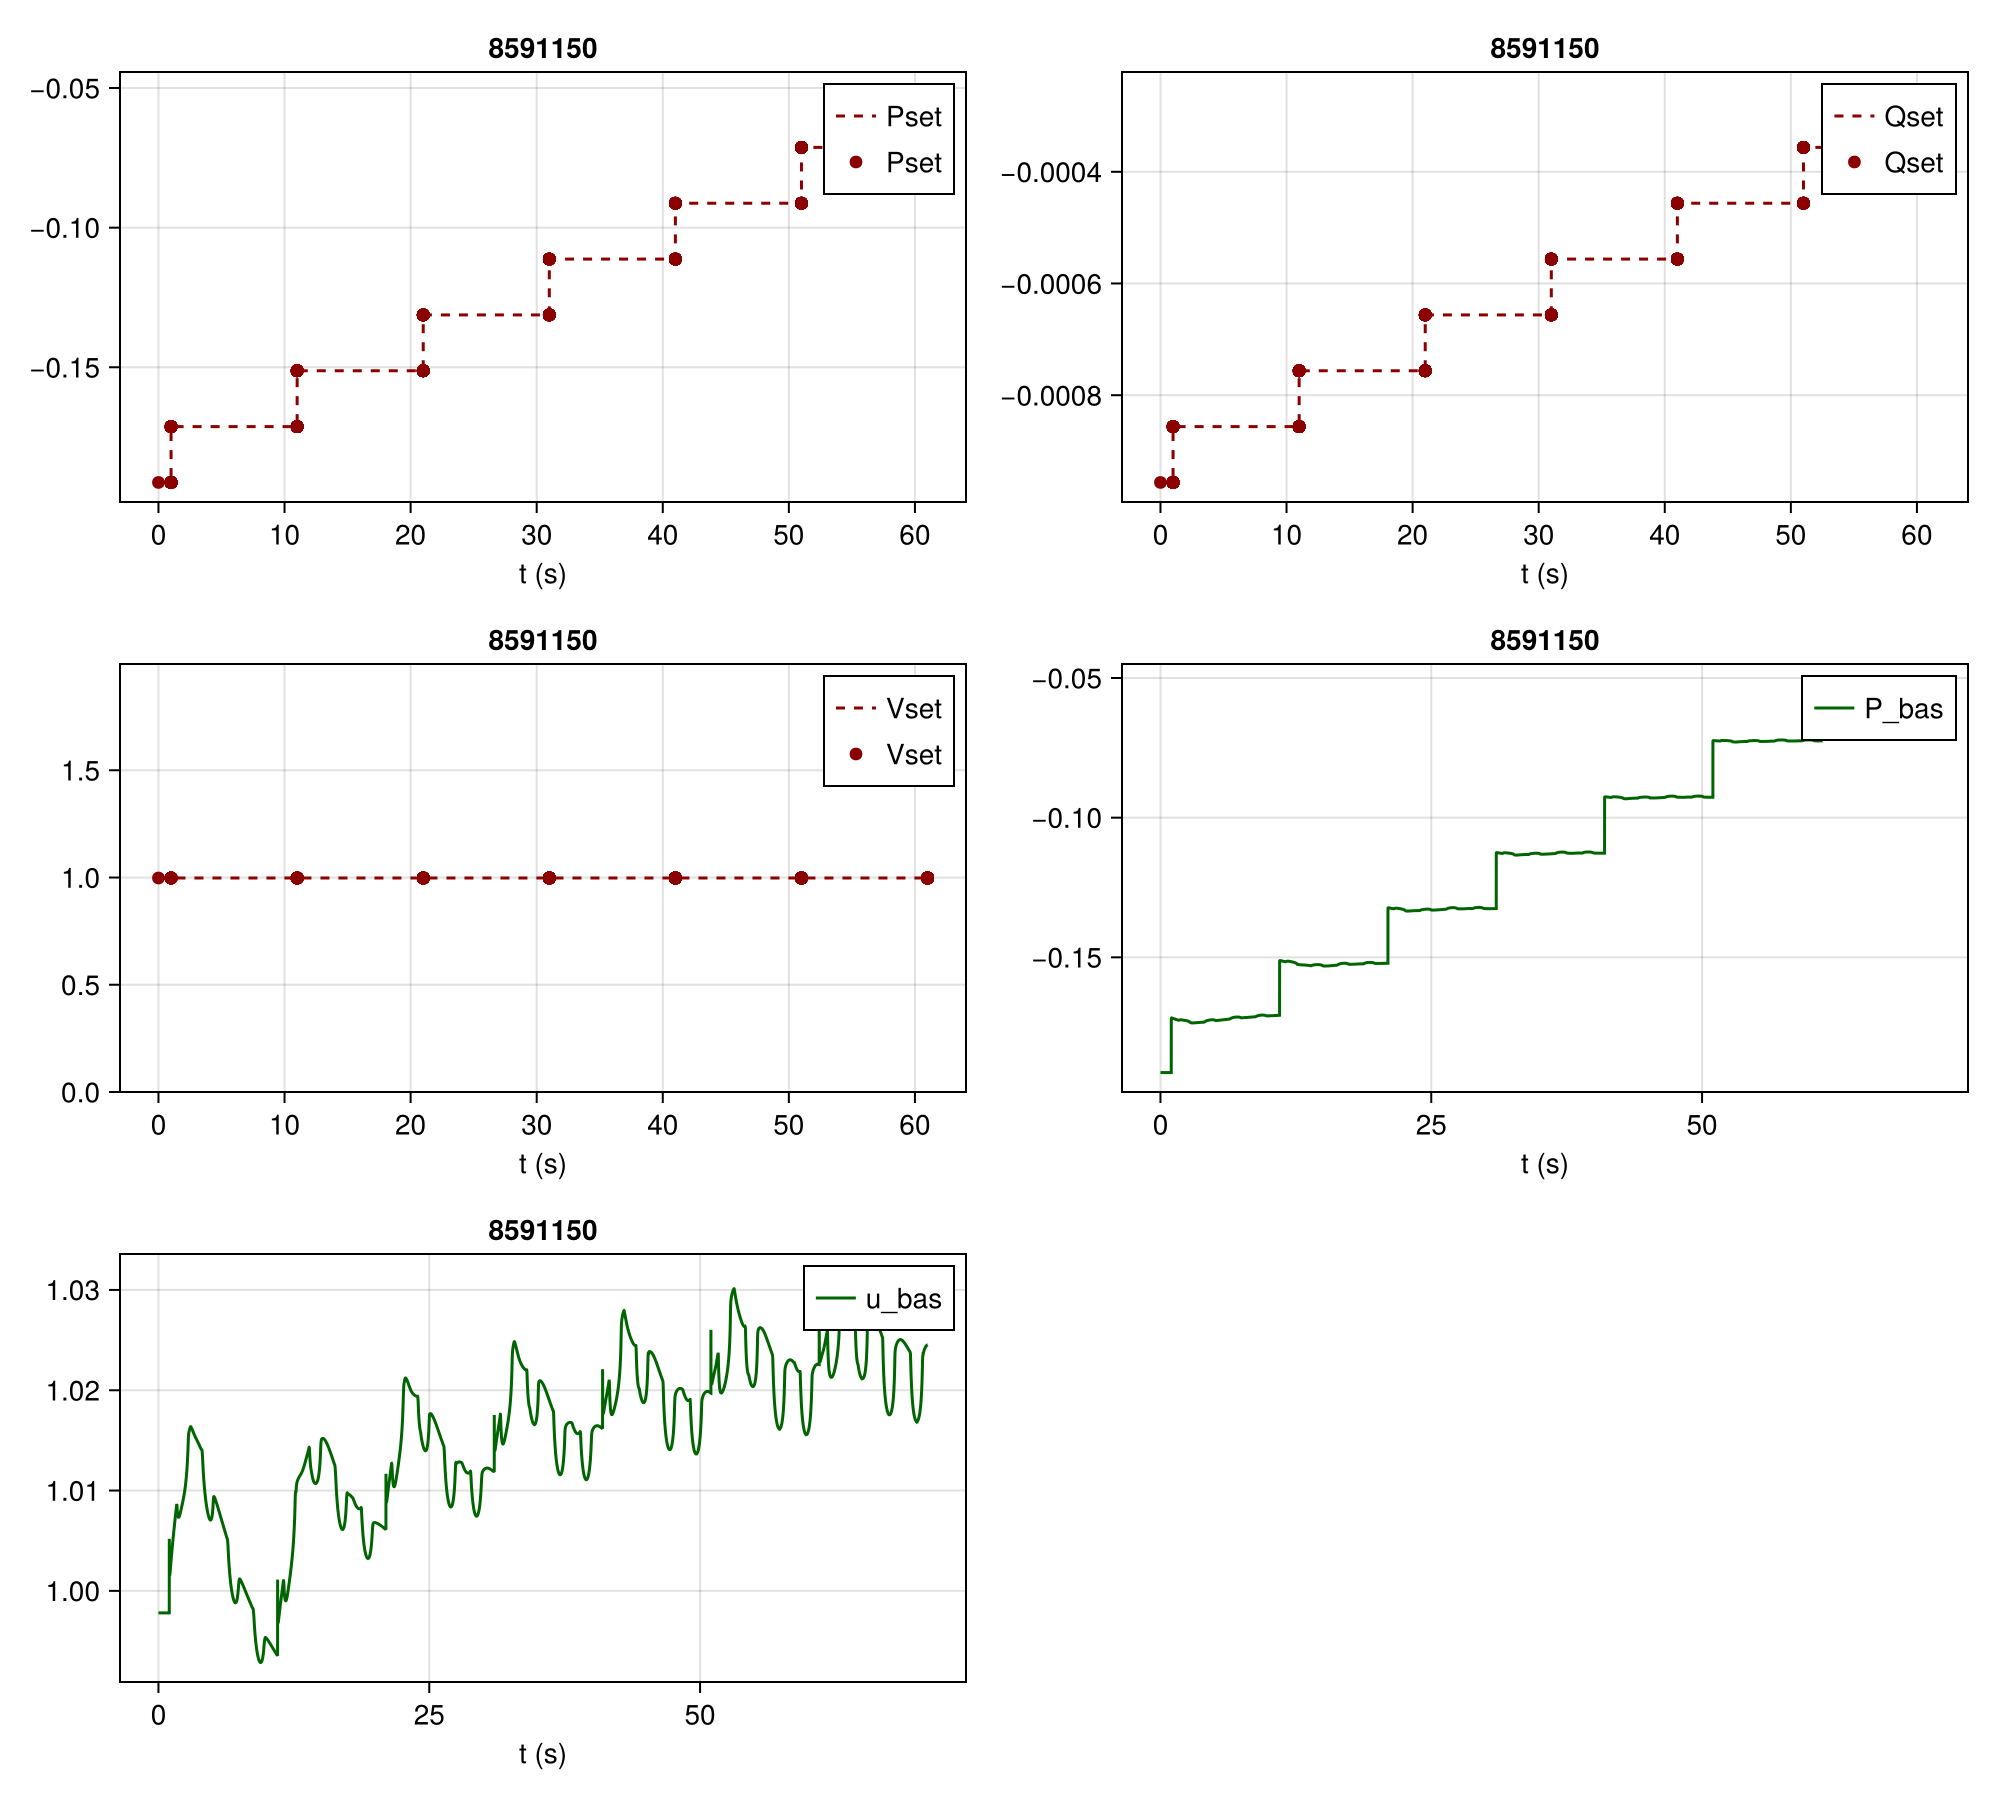

In [10]:
let
    cols = 2
    # Define the variables, their labels, and colors
    vars = [
        (:load₊Pset, "Pset", :darkred),
        (:load₊Qset, "Qset", :darkred),
        (:load₊Vset, "Vset", :darkred),
        (:busbar₊P, "P_bas", :darkgreen),
        (:busbar₊u_mag, "u_bas", :darkgreen)
    ]
    
    # Calculate rows needed based on 2 columns
    rows = ceil(Int, length(vars) / cols)
    
    # Initialize figure with an appropriate size
    fig = Figure(size = (500 * cols, rows * 300))
    
    # Loop through and create a subplot for each variable
    for (i, (var_sym, label_str, col_color)) in enumerate(vars)
        r = div(i - 1, cols) + 1
        c = mod(i - 1, cols) + 1
        
        # Create axis in the grid position (r, c)
        ax = Axis(fig[r, c], title="8591150", xlabel="t (s)")
        # Plot the specific variable
        lines!(ax, sol2, idxs=VIndex(Symbol(data.nodes[877]), var_sym), color=col_color, label=label_str)
        
        # Optional: add legend per subplot if needed
        axislegend(ax, position=:rt)
    end
    
    fig
end

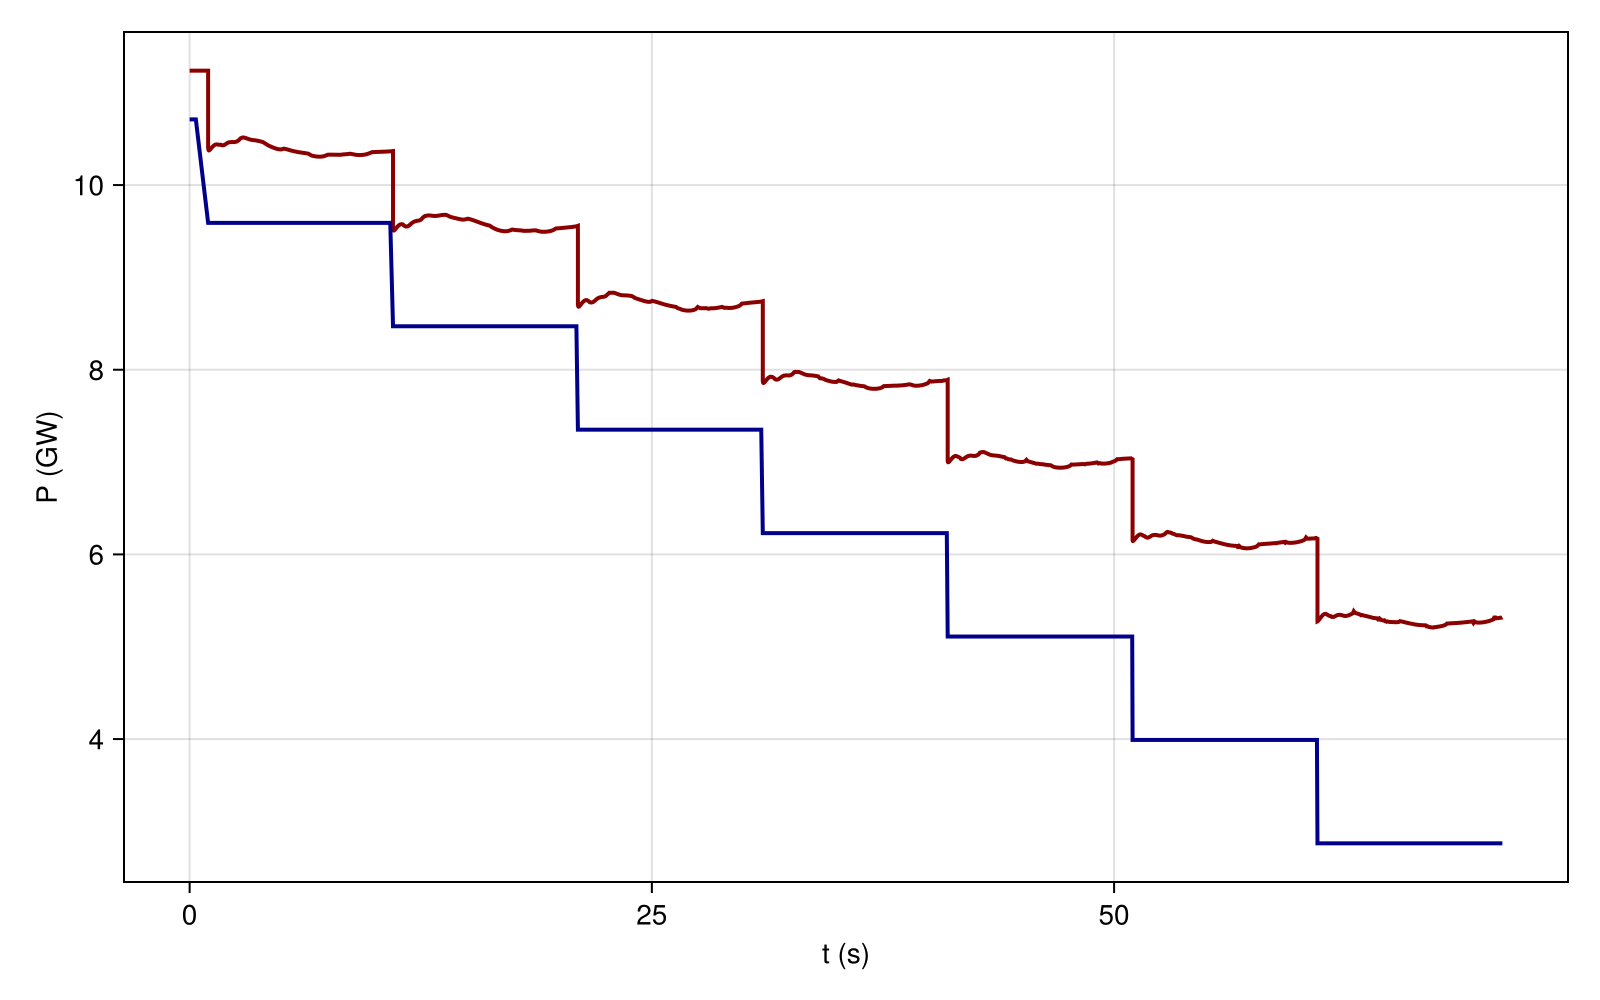

In [17]:
let
    fig = Figure(size = (800, 500))
    ax = Axis(fig[1, 1], title = "", xlabel = "t (s)", ylabel = "P (GW)")

    total_power = zeros(length(sol2.t))
    total_load = zeros(length(sol2.t))
    
    for name in data.nodes     
        parts = split(string(name), "_")

        if length(parts) != 2
            continue
        end

        if parts[2] == "plant"
            total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(name), :busbar₊P)).u
        end

        if parts[2] == "load"
            total_load .-= sol2(sol2.t, idxs=VIndex(Symbol(name), :load₊Pset)).u
        end
    end

    lines!(ax, sol2.t, total_power, color = :darkred, linewidth = 2)

    total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:Germany), :busbar₊P)).u
    total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:France), :busbar₊P)).u
    total_power .+= sol2(sol2.t, idxs=VIndex(Symbol(:Netherlands), :busbar₊P)).u

    # lines!(ax, sol2.t, total_power, color = :darkred, linewidth = 2, linestyle = :dot)

    lines!(ax, sol2.t, total_load, color = :darkblue, linewidth = 2)

    fig
end